0. Setup Awal

In [58]:
import warnings
from pathlib import Path

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

warnings.filterwarnings('ignore')

plt.style.use(
    'seaborn-v0_8-whitegrid'
    if 'seaborn-v0_8-whitegrid'
    in plt.style.available
    else 'default'
)

plt.rcParams['figure.dpi'] = 120

BASE_DIR = Path.cwd()

OUTPUT_DIR = (
    BASE_DIR
    / 'outputAnalisisPerbandingan'
)

OUTPUT_DIR.mkdir(
    parents=True,
    exist_ok=True
)

print(
    'Folder kerja:',
    Path.cwd()
)

print(
    'BASE_DIR:',
    BASE_DIR
)

print(
    'OUTPUT_DIR:',
    OUTPUT_DIR
)

Folder kerja: D:\My Files\File Penting\MachineLearning\Pertemuan_4\Studi_Kasus
BASE_DIR: D:\My Files\File Penting\MachineLearning\Pertemuan_4\Studi_Kasus
OUTPUT_DIR: D:\My Files\File Penting\MachineLearning\Pertemuan_4\Studi_Kasus\outputAnalisisPerbandingan


1. Load Hasil Evaluasi

1.1 Load 6 File Evaluasi

In [59]:
files = {
    'K-Means Euclidean':
        BASE_DIR
        / 'outputKmeansEuclidian'
        / 'evaluasi_kmeans_euclidean.xlsx',

    'K-Means Manhattan':
        BASE_DIR
        / 'outputKmeansManhattan'
        / 'evaluasi_kmeans_manhattan.xlsx',

    'K-Means Cosine':
        BASE_DIR
        / 'outputKmeansCosine'
        / 'evaluasi_kmeans_cosine.xlsx',

    'DBSCAN Euclidean':
        BASE_DIR
        / 'outputDBSCANEuclidian'
        / 'evaluasi_dbscan_euclidean.xlsx',

    'DBSCAN Manhattan':
        BASE_DIR
        / 'outputDBSCANManhattan'
        / 'evaluasi_dbscan_manhattan.xlsx',

    'DBSCAN Cosine':
        BASE_DIR
        / 'outputDBSCANCosine'
        / 'evaluasi_dbscan_cosine.xlsx'
}

In [60]:
evaluation_results = []

for model_name, file_path in files.items():

    result = pd.read_excel(
        file_path,
        sheet_name='Ringkasan_Evaluasi'
    )

    result['Model_Comparison'] = model_name

    evaluation_results.append(
        result
    )

comparison_df = pd.concat(
    evaluation_results,
    ignore_index=True
)

comparison_df

,Model,Distance Metric,Jumlah Cluster,Silhouette Score (↑),Davies-Bouldin Index (↓),Calinski-Harabasz Index (↑),Execution Time (s) (↓),Iterations (↓),Objective Value (SSE) (↓),Alokasi Memori (MB),Model_Comparison,Objective Value (L1) (↓),Objective Value (Cosine Distance) (↓),eps,min_samples,Jumlah Noise,Noise (%)
0,K-Means Euclidean,Euclidean Distance (L2),3,0.1116,2.4888,7524.35,0.81497,10.0,1191398.52,23.86,K-Means Euclidean,NaN,NaN,NaN,NaN,NaN,NaN
1,K-Means Manhattan,Manhattan Distance (L1),4,0.0912,3.9385,4992.48,1.94458,21.0,NaN,10.64,K-Means Manhattan,1066388.04,NaN,NaN,NaN,NaN,NaN
2,K-Means Cosine Similarity,Cosine Distance (1 - Cosine Similarity),2,0.2574,2.3324,9093.79,0.18952,7.0,NaN,13.63,K-Means Cosine,NaN,30356.33,NaN,NaN,NaN,NaN
3,DBSCAN Euclidean,Euclidean Distance (L2),2,0.2068,1.5905,7019.23,3.33168,NaN,NaN,34.53,DBSCAN Euclidean,NaN,NaN,4.0423,10.0,3309.0,6.62
4,DBSCAN Manhattan,Manhattan Distance (L1),3,-0.0174,1.2339,1.60,17.08385,NaN,NaN,34.53,DBSCAN Manhattan,NaN,NaN,14.2974,10.0,4005.0,8.01
5,DBSCAN Cosine Similarity,Cosine Distance (1 - Cosine Similarity),54,0.5752,2.0366,71.64,44.51321,NaN,NaN,2596.05,DBSCAN Cosine,NaN,NaN,0.1896,10.0,42546.0,85.09


2. Ringkasan Keenam Model

2.1 Tabel Perbandingan

In [61]:
comparison_table = comparison_df[
    [
        'Model_Comparison',
        'Jumlah Cluster',
        'Silhouette Score (↑)',
        'Davies-Bouldin Index (↓)',
        'Calinski-Harabasz Index (↑)',
        'Execution Time (s) (↓)',
        'Alokasi Memori (MB)'
    ]
].copy()

comparison_table

,Model_Comparison,Jumlah Cluster,Silhouette Score (↑),Davies-Bouldin Index (↓),Calinski-Harabasz Index (↑),Execution Time (s) (↓),Alokasi Memori (MB)
0,K-Means Euclidean,3,0.1116,2.4888,7524.35,0.81497,23.86
1,K-Means Manhattan,4,0.0912,3.9385,4992.48,1.94458,10.64
2,K-Means Cosine,2,0.2574,2.3324,9093.79,0.18952,13.63
3,DBSCAN Euclidean,2,0.2068,1.5905,7019.23,3.33168,34.53
4,DBSCAN Manhattan,3,-0.0174,1.2339,1.60,17.08385,34.53
5,DBSCAN Cosine,54,0.5752,2.0366,71.64,44.51321,2596.05


2.2 Validitas Hasil Cluster

Keenam model telah menghasilkan lebih dari satu cluster sehingga seluruh model dapat dievaluasi menggunakan Silhouette Score, Davies-Bouldin Index, dan Calinski-Harabasz Index. Namun, interpretasi hasil DBSCAN perlu mempertimbangkan jumlah noise karena evaluasi internal hanya dihitung pada data yang tidak berlabel noise. Selain itu, jumlah cluster yang terbentuk berbeda antar-model karena K-Means menentukan jumlah cluster berdasarkan parameter k, sedangkan DBSCAN membentuk cluster berdasarkan kepadatan data.

3. Perbandingan Kualitas Clustering

3.1 Silhouette Score

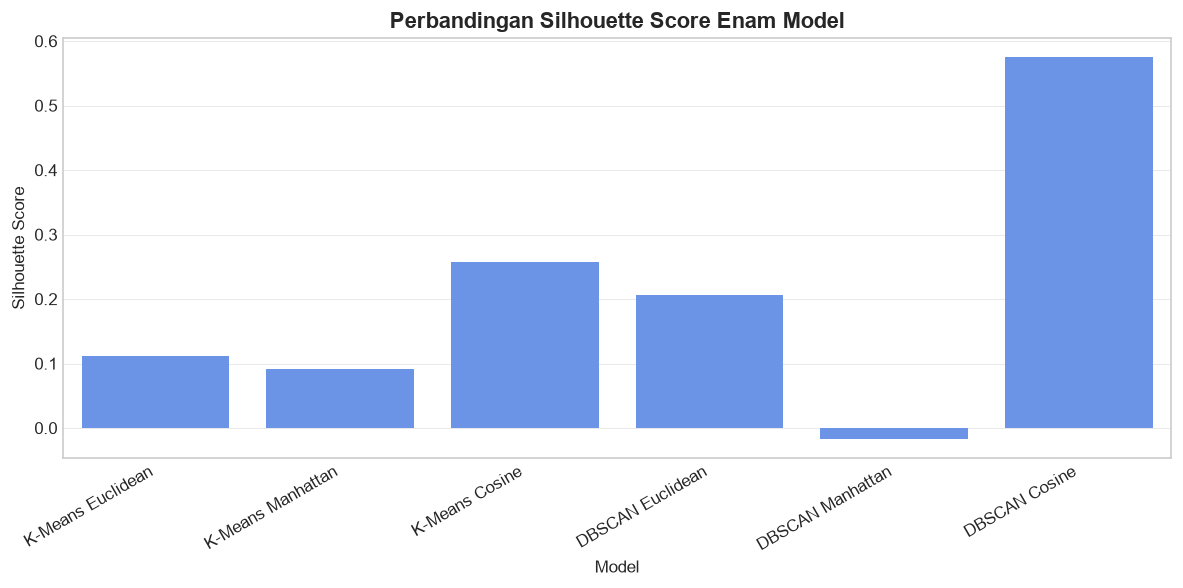

In [62]:
plt.figure(
    figsize=(10, 5)
)

sns.barplot(
    data=comparison_df,
    x='Model_Comparison',
    y='Silhouette Score (↑)'
)

plt.title(
    'Perbandingan Silhouette Score '
    'Enam Model',
    fontsize=13,
    fontweight='bold'
)

plt.xlabel('Model')
plt.ylabel('Silhouette Score')

plt.xticks(
    rotation=30,
    ha='right'
)

plt.tight_layout()
plt.show()

3.2 Davies-Bouldin Index

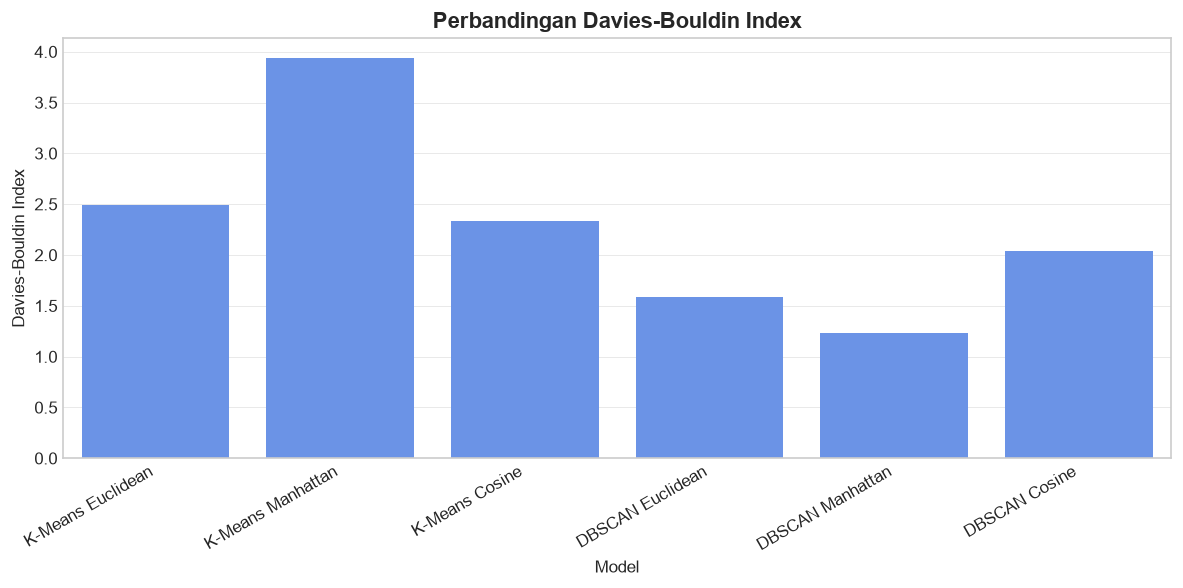

In [63]:
plt.figure(
    figsize=(10, 5)
)

sns.barplot(
    data=comparison_df,
    x='Model_Comparison',
    y='Davies-Bouldin Index (↓)'
)

plt.title(
    'Perbandingan Davies-Bouldin Index',
    fontsize=13,
    fontweight='bold'
)

plt.xlabel('Model')
plt.ylabel('Davies-Bouldin Index')

plt.xticks(
    rotation=30,
    ha='right'
)

plt.tight_layout()
plt.show()

3.3 Calinski-Harabasz Index

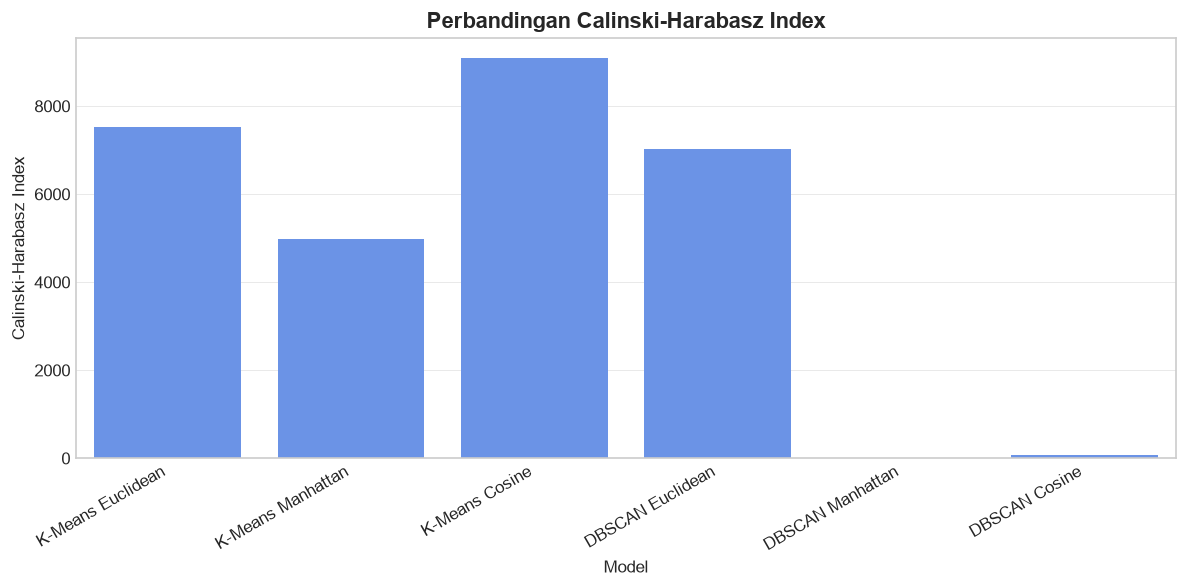

In [64]:
plt.figure(
    figsize=(10, 5)
)

sns.barplot(
    data=comparison_df,
    x='Model_Comparison',
    y='Calinski-Harabasz Index (↑)'
)

plt.title(
    'Perbandingan Calinski-Harabasz Index',
    fontsize=13,
    fontweight='bold'
)

plt.xlabel('Model')
plt.ylabel('Calinski-Harabasz Index')

plt.xticks(
    rotation=30,
    ha='right'
)

plt.tight_layout()
plt.show()

4. Perbandingan Efisiensi

4.1 Execution Time

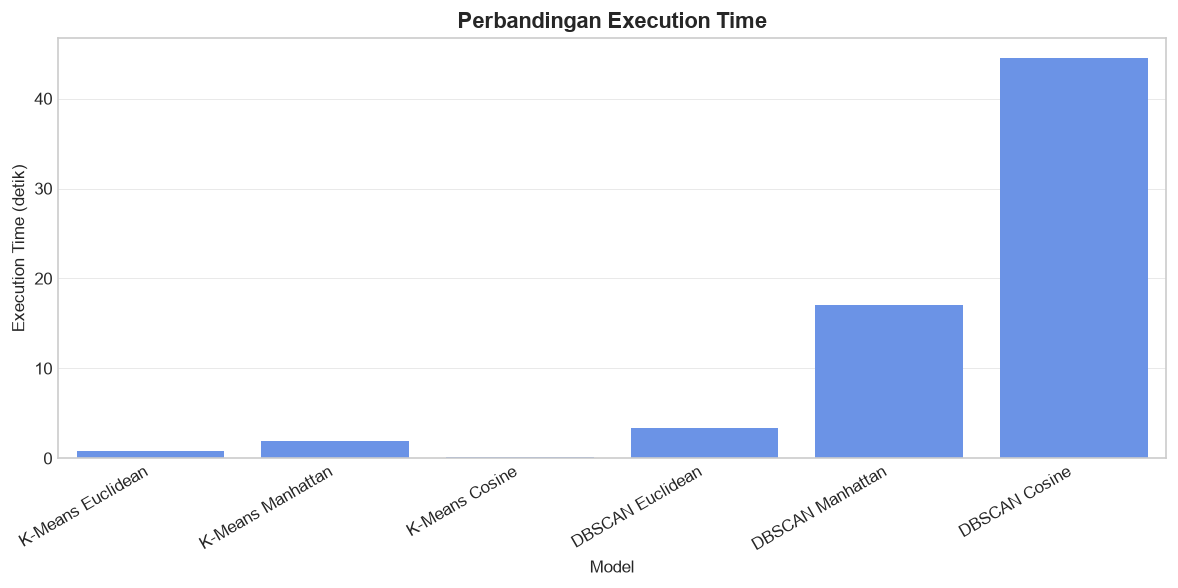

In [65]:
plt.figure(
    figsize=(10, 5)
)

sns.barplot(
    data=comparison_df,
    x='Model_Comparison',
    y='Execution Time (s) (↓)'
)

plt.title(
    'Perbandingan Execution Time',
    fontsize=13,
    fontweight='bold'
)

plt.xlabel('Model')
plt.ylabel('Execution Time (detik)')

plt.xticks(
    rotation=30,
    ha='right'
)

plt.tight_layout()
plt.show()

4.2 Alokasi Memori

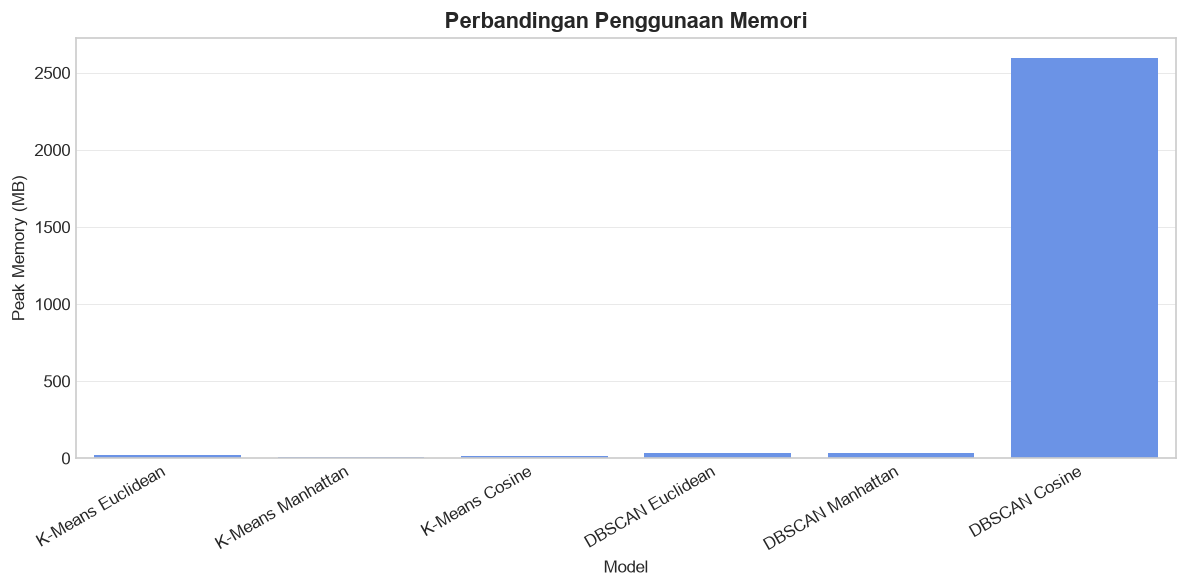

In [66]:
plt.figure(
    figsize=(10, 5)
)

sns.barplot(
    data=comparison_df,
    x='Model_Comparison',
    y='Alokasi Memori (MB)'
)

plt.title(
    'Perbandingan Penggunaan Memori',
    fontsize=13,
    fontweight='bold'
)

plt.xlabel('Model')
plt.ylabel('Peak Memory (MB)')

plt.xticks(
    rotation=30,
    ha='right'
)

plt.tight_layout()
plt.show()

5. Perbandingan Hasil Pembentukan Cluster

5.1 Jumlah Cluster

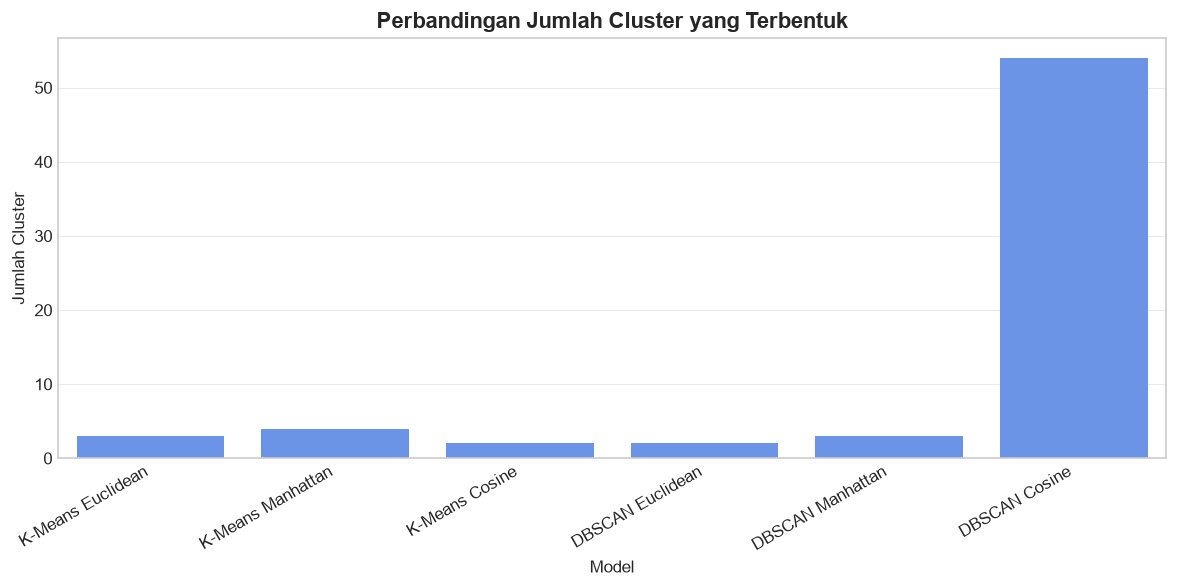

In [67]:
plt.figure(
    figsize=(10, 5)
)

sns.barplot(
    data=comparison_df,
    x='Model_Comparison',
    y='Jumlah Cluster'
)

plt.title(
    'Perbandingan Jumlah Cluster yang Terbentuk',
    fontsize=13,
    fontweight='bold'
)

plt.xlabel('Model')
plt.ylabel('Jumlah Cluster')

plt.xticks(
    rotation=30,
    ha='right'
)

plt.tight_layout()
plt.show()

5.2 Noise DBSCAN

In [68]:
dbscan_df = comparison_df[
    comparison_df[
        'Model_Comparison'
    ].str.contains(
        'DBSCAN'
    )
].copy()

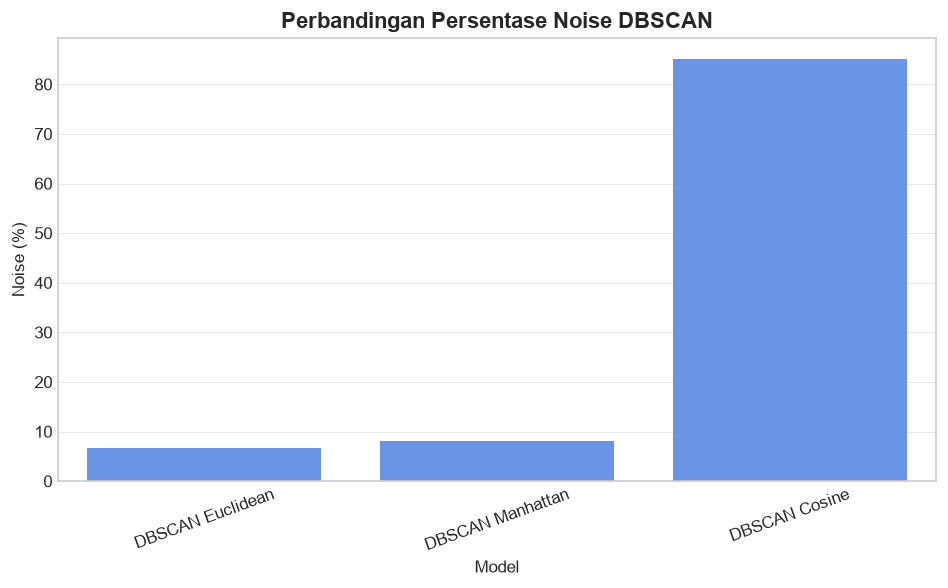

In [69]:
plt.figure(
    figsize=(8, 5)
)

sns.barplot(
    data=dbscan_df,
    x='Model_Comparison',
    y='Noise (%)'
)

plt.title(
    'Perbandingan Persentase Noise DBSCAN',
    fontsize=13,
    fontweight='bold'
)

plt.xlabel('Model')
plt.ylabel('Noise (%)')

plt.xticks(
    rotation=20
)

plt.tight_layout()
plt.show()

6. Perbandingan Visualisasi Cluster

6.1 K-Means

In [70]:
kmeans_df = comparison_df[
    comparison_df[
        'Model_Comparison'
    ].str.contains(
        'K-Means'
    )
].copy()

kmeans_df

,Model,Distance Metric,Jumlah Cluster,Silhouette Score (↑),Davies-Bouldin Index (↓),Calinski-Harabasz Index (↑),Execution Time (s) (↓),Iterations (↓),Objective Value (SSE) (↓),Alokasi Memori (MB),Model_Comparison,Objective Value (L1) (↓),Objective Value (Cosine Distance) (↓),eps,min_samples,Jumlah Noise,Noise (%)
0,K-Means Euclidean,Euclidean Distance (L2),3,0.1116,2.4888,7524.35,0.81497,10.0,1191398.52,23.86,K-Means Euclidean,NaN,NaN,NaN,NaN,NaN,NaN
1,K-Means Manhattan,Manhattan Distance (L1),4,0.0912,3.9385,4992.48,1.94458,21.0,NaN,10.64,K-Means Manhattan,1066388.04,NaN,NaN,NaN,NaN,NaN
2,K-Means Cosine Similarity,Cosine Distance (1 - Cosine Similarity),2,0.2574,2.3324,9093.79,0.18952,7.0,NaN,13.63,K-Means Cosine,NaN,30356.33,NaN,NaN,NaN,NaN


6.2 DBSCAN

In [71]:
dbscan_df = comparison_df[
    comparison_df[
        'Model_Comparison'
    ].str.contains(
        'DBSCAN'
    )
].copy()

dbscan_df

,Model,Distance Metric,Jumlah Cluster,Silhouette Score (↑),Davies-Bouldin Index (↓),Calinski-Harabasz Index (↑),Execution Time (s) (↓),Iterations (↓),Objective Value (SSE) (↓),Alokasi Memori (MB),Model_Comparison,Objective Value (L1) (↓),Objective Value (Cosine Distance) (↓),eps,min_samples,Jumlah Noise,Noise (%)
3,DBSCAN Euclidean,Euclidean Distance (L2),2,0.2068,1.5905,7019.23,3.33168,NaN,NaN,34.53,DBSCAN Euclidean,NaN,NaN,4.0423,10.0,3309.0,6.62
4,DBSCAN Manhattan,Manhattan Distance (L1),3,-0.0174,1.2339,1.60,17.08385,NaN,NaN,34.53,DBSCAN Manhattan,NaN,NaN,14.2974,10.0,4005.0,8.01
5,DBSCAN Cosine Similarity,Cosine Distance (1 - Cosine Similarity),54,0.5752,2.0366,71.64,44.51321,NaN,NaN,2596.05,DBSCAN Cosine,NaN,NaN,0.1896,10.0,42546.0,85.09


7. Analisis Akhir

- K-Means Cosine menghasilkan 2 cluster dengan Silhouette tertinggi (0,2574) dan Calinski-Harabasz tertinggi (9093,79), serta memiliki waktu eksekusi paling cepat, yaitu sekitar 0,19 detik.
- K-Means Euclidean menghasilkan 3 cluster dengan kualitas clustering cukup baik, tetapi nilai Silhouette masih lebih rendah dibandingkan K-Means Cosine.
- K-Means Manhattan menghasilkan 4 cluster, tetapi memiliki Silhouette paling rendah di antara ketiga K-Means dan Davies-Bouldin Index yang relatif tinggi.
- DBSCAN Euclidean memberikan hasil paling baik di antara model DBSCAN, dengan 2 cluster, Silhouette 0,2068, DBI 1,5905, serta noise yang relatif rendah sebesar 6,62%.
- DBSCAN Manhattan menghasilkan 3 cluster dengan Silhouette -0,0174, sehingga pemisahan cluster masih kurang baik meskipun persentase noise hanya 8,01%.
- DBSCAN Cosine menghasilkan 54 cluster, tetapi 85.09% data menjadi noise dan membutuhkan waktu serta memori paling besar, sehingga hasilnya kurang efisien untuk dataset ini.
- Secara umum, K-Means lebih efisien dan menghasilkan pembagian cluster yang lebih stabil, sedangkan DBSCAN lebih sensitif terhadap eps, min_samples, dan distance metric yang digunakan.

Berdasarkan keseimbangan kualitas clustering dan efisiensi komputasi, model yang paling optimal pada eksperimen ini adalah K-Means Cosine, karena memiliki Silhouette Score dan Calinski-Harabasz Index tertinggi sekaligus waktu eksekusi yang paling rendah.